In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

import numpy as np
import math
from tqdm.auto import tqdm
from data_fitting.module_fitzcu import *
from singleshotplot import hist as histplot
from qick import *
from qick.asm_v2 import AveragerProgramV2
from qick.asm_v2 import QickSpan, QickSweep1D
from qick.asm_v2 import AsmV2
import json
import datetime
import pprint as pp

In [2]:
import Pyro4
from qick import QickConfig
Pyro4.config.SERIALIZER = "pickle"
Pyro4.config.PICKLE_PROTOCOL_VERSION=4

ns_host = "192.168.10.7"
ns_port = 8888
proxy_name = "myqick"

ns = Pyro4.locateNS(host=ns_host, port=ns_port)
soc = Pyro4.Proxy(ns.lookup(proxy_name))
soccfg = QickConfig(soc.get_cfg())
print(soccfg)

QICK running on ZCU216, software version 0.2.342

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc timing clock, DAC tile 0, DAC tile 1, DAC tile 3], [DAC tile 2], [ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 Msps, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2,

In [3]:
from os.path import isdir, join
import os
import requests
# from datetime import datetime
import datetime
from numpy import pi
import re
import Labber

def hdf5_generator(
        filepath: str,
        x_info:dict, z_info:dict, 
        y_info:dict = None, comment = None, tag = None):
    np.float=float
    np.bool=bool
    zdata = z_info['values']
    z_info.update({'complex': True, 'vector': False})
    log_channels = [z_info]
    step_channels = list(filter(None, [x_info, y_info]))

    fObj = Labber.createLogFile_ForData(filepath, log_channels, step_channels)
    if y_info:
        for trace in zdata:
            fObj.addEntry({z_info['name']: trace})
    else:
        fObj.addEntry({z_info['name']: zdata})

    if comment: fObj.setComment(comment)
    if tag: fObj.setTags(tag)
    


def get_next_filename_labber(dest_path: str, exp_name: str, yoko:str=None) -> str:
    # make sure dest_path is absolute path
    dest_path = os.path.abspath(dest_path)
    yy, mm, dd = datetime.datetime.today().strftime('%Y-%m-%d').split('-')
    save_path = os.path.join(dest_path, yy, mm, f"Data_{mm}{dd}")
    os.makedirs(save_path, exist_ok=True)

    existing_files = [f for f in os.listdir(save_path) if re.match(
        rf"{re.escape(exp_name)}_\d+\.hdf5", f)]
    next_index = max([int(re.search(r"_(\d+)", f).group(1))
                     for f in existing_files], default=0) + 1
    if yoko is not None:
        return os.path.join(save_path, f"{exp_name}_{yoko:.2f}mA")
    else:
        return os.path.join(save_path, f"{exp_name}_{next_index}")

data_path = r'C:\Users\QEL\Desktop\2DQ12_round2\mux'

# Connect yoko

In [4]:
from YOKOGS200 import YOKOGS200
import pyvisa 
rm = pyvisa.ResourceManager()
yoko_connect='USB0::0x0B21::0x0039::91WB18859::INSTR'
yoko = YOKOGS200(yoko_connect, rm)

In [5]:
yoko.SetMode('current')
yokocurrent = 2 *1e-3
yoko.SetCurrent(yokocurrent)
yoko.GetCurrent()

0.002

# System config

In [6]:
r1 = 5351.9
r2 = 5494.19
r3 = 5667.69
r4 = 5797.6
r5 = 5917.51
r6 = 6051.89

r = [r1, r2, r3, r4, r5, r6]
res_mixer = round(np.sum(r)/6)
res_mixer=5800
q1, q2, q3, q4, q5, q6 = [7, 0, 1, 2, 0, 14]
q = [q1, q2, q3, q4, q5, q6]

In [7]:
config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': r,
          'mixer_freq': res_mixer,
          'res_gains': [0.5]*6,
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.72,
          'res_len': 5,
          'ro_len': 5,
          'relax_delay':50
         }

qb_cfg={
    'qb_ch':q,
    'f_q': 4200,
    'qmixer_freq': 4200,
    'q_len':5,
    'q_gain': 0.01,
    'sigma': 0.5,
}

config = {**config, **qb_cfg}

In [209]:
class MixMuxGenMuxROProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
config.update({
    'res_len': 0.3, 
    'ro_len':1.3, 
    'res_gains': [1.0]*6, 
    'res_freqs':np.array(r)-15, 
    'trig_time': 0
    }) 


prog = MixMuxGenMuxROProgram(soccfg, reps=1, final_delay=0.2, cfg=config)
iq_list = prog.acquire_decimated(soc, rounds=1000)
t = prog.get_time_axis(ro_index=0)

fig, axes = plt.subplots(len(config['ro_chs']), 1, figsize=(10,10))
for i, ch in enumerate(config['ro_chs']):
    plot = axes[i]
    plot.plot(t, iq_list[i][:,0], label="I value")
    plot.plot(t, iq_list[i][:,1], label="Q value")
    plot.plot(t, np.abs(iq_list[i].dot([1,1j])), label="magnitude")
    plot.axvline(0.75)
    plot.legend()
    plot.set_ylabel("a.u.")
    plot.set_xlabel("us")


# for i, ch in enumerate(config['ro_chs']):
#     # frequency-matching cross-check
#     f_gen = prog.res_chs[config['res_ch']]['mux_tones'][i]['freq_rounded']
#     f_ro = prog.ro_chs[ch]['ro_config']['f_rounded']
#     print("pulse freq %f MHz, RO freq %f MHz, difference %e MHz"%(f_gen, f_ro, f_gen-f_ro))

  0%|          | 0/1000 [00:00<?, ?it/s]

# Mux OneTone

In [61]:
class MuxOneTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)



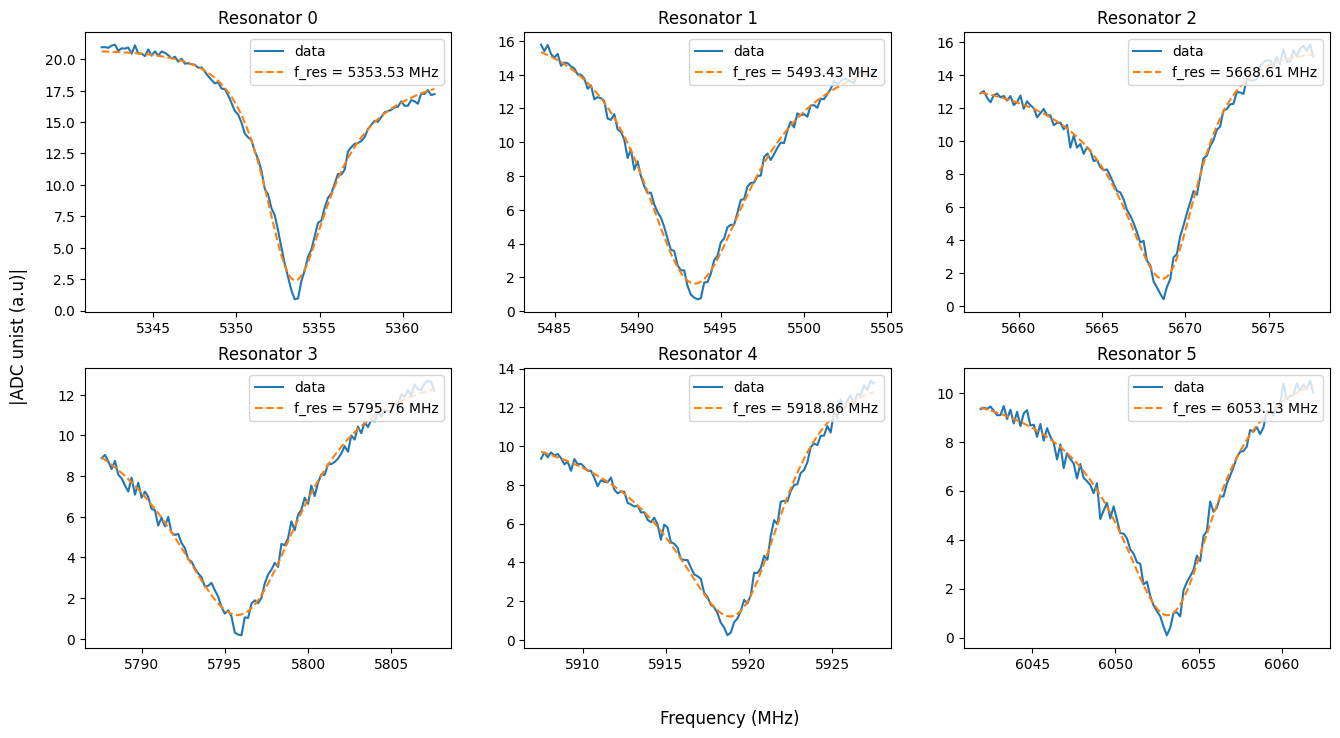

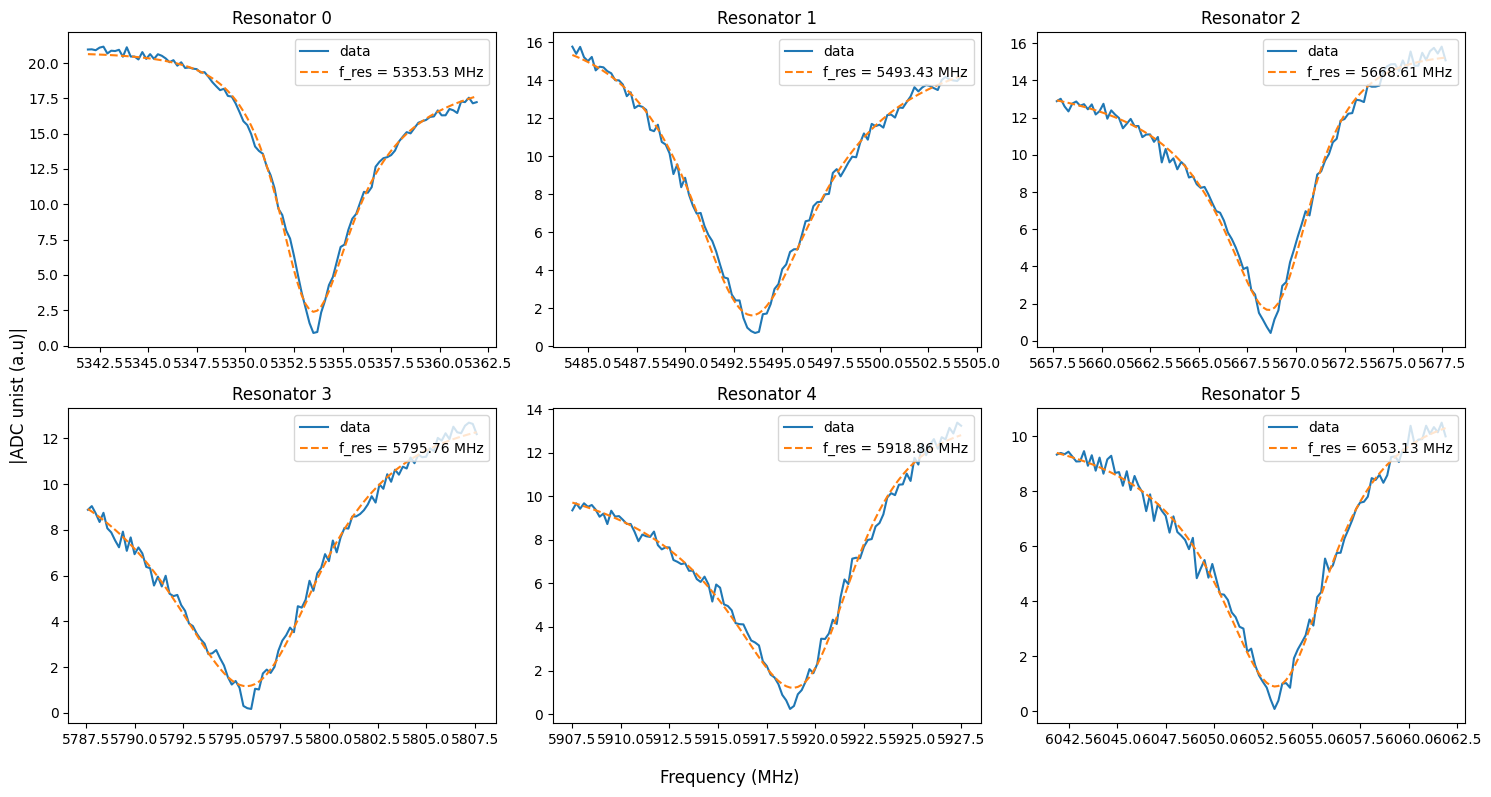

In [62]:
# Configuration parameters
n_roch = 6                           # Number of resonators
F_Span = 10                          # Frequency span (MHz)
F_Steps = 101                        # Number of frequency points
sweep = np.linspace(-F_Span, F_Span, F_Steps)
config['res_gains'] = [0.5] * n_roch  # Gain for each resonator

# Data containers
z_list = [[] for _ in range(n_roch)]
popt = [None] * n_roch              # Fitted parameters
fit_res = [None] * n_roch           # Extracted resonance frequencies

# Create subplots with 3 columns per row
n_rows = math.ceil(n_roch / 3)
fig, ax = plt.subplots(n_rows, 3, figsize=(5 * 3, 4 * n_rows))
ax = ax.flatten() if n_rows > 1 else np.atleast_1d(ax)
handle = display(fig, display_id=True)
fig.supxlabel("Frequency (MHz)")
fig.supylabel("|ADC|")
plt.subplots_adjust(left=0.07)

for sweep_idx, delta in tqdm(enumerate(sweep), total=len(sweep), desc="Frequency Sweep"):
    # Update frequency for this sweep point
    config['res_freqs'] = np.array(r) + delta
    prog = MuxOneTone(soccfg, reps=100, final_delay=0.5, cfg=config)
    results = prog.acquire(soc, rounds=10, progress=False)

    # Collect I/Q data
    for res_idx, res in enumerate(results):
        z = res[0][0] + 1j * res[0][1]
        z_list[res_idx].append(z)

    # Live update plot
    for i in range(n_roch):
        ax[i].cla()
        freq_sweep = r[i] + sweep[:sweep_idx + 1]
        mag_response = np.abs(z_list[i])
        ax[i].plot(freq_sweep, mag_response, label='data')
        ax[i].set_title(f"Resonator {i}")
        ax[i].legend(loc='upper right')
    fig.suptitle(f"Sweep detune = {delta:.4f} MHz")
    handle.update(fig)
plt.tight_layout()
clear_output(wait=False)
plt.close(fig)

# Final fit and result plot
fig, ax = plt.subplots(n_rows, 3, figsize=(5 * 3, 4 * n_rows))
ax = ax.flatten() if n_rows > 1 else np.atleast_1d(ax)
handle = display(fig, display_id=True)
fig.supxlabel("Frequency (MHz)")
fig.supylabel("|ADC unist (a.u)|")
plt.subplots_adjust(left=0.07)
for i in range(n_roch):
    freq_sweep = r[i] + sweep
    mag_response = np.abs(z_list[i])

    ax[i].plot(freq_sweep, mag_response, label='data')
    popt[i], _ = fit_asym_lor(freq_sweep, mag_response)  # Fit with asymmetric Lorentzian
    fit_curve = asym_lorfunc(freq_sweep, *popt[i])
    ax[i].plot(freq_sweep, fit_curve, '--', label=f'f_res = {popt[i][2]:.2f} MHz')

    ax[i].set_title(f"Resonator {i}")
    ax[i].legend(loc='upper right')
    fit_res[i] = round(popt[i][2], 2)  # Store fitted frequency
handle.update(fig)
plt.tight_layout()


In [191]:
data_path = data_path

for idx in range(n_roch):
        exp_name = f"res onetone mux r{idx}"
        file_path = get_next_filename_labber(data_path, exp_name, 2e-3)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + sweep)*1e6},  
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(z_list[idx])},
                comment=f'',
                tag='OneTone'
        )

2025-07-22 12:45:09,068 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 12:45:09,243 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 12:45:09,385 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 12:45:09,572 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 12:45:09,731 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 12:45:09,872 - SR_Network:BlockingClient - Error: Socket operation timed out


## Mux OneTone Punchout

In [90]:
class MuxPunchout(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0, 1, 2, 3, 4, 5],
                      )
        
    def _body(self, cfg):
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)


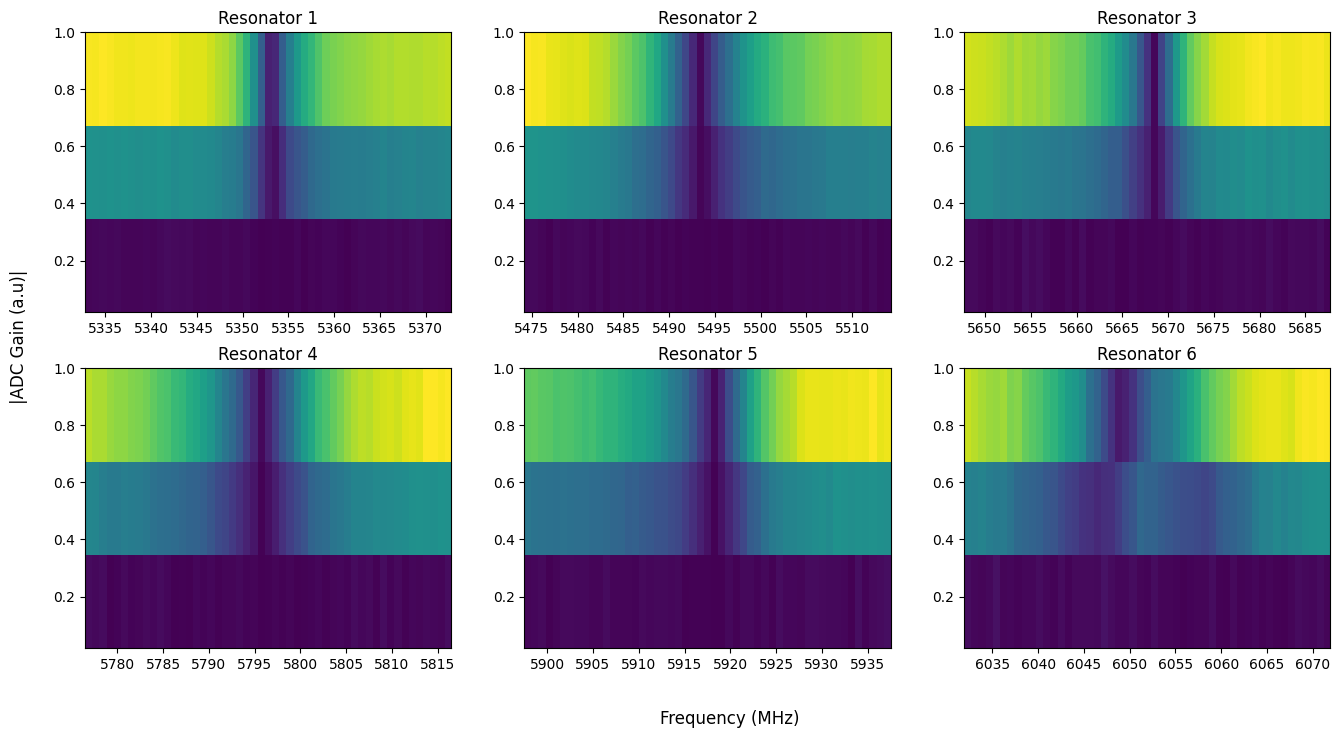

Gain sweep:   0%|          | 0/3 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/51 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/51 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/51 [00:00<?, ?it/s]

In [ ]:
from tqdm.auto import tqdm
n_roch = 6

F_Sapn = 20
F_Steps = 51

G_Start = 0.02
G_Stop = 1
G_Steps = 3

fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps)
gain = np.linspace(G_Start, G_Stop, G_Steps)

n_rows = math.ceil(n_roch / 3)
fig, ax = plt.subplots(n_rows, 3, figsize=(5 * 3, 4 * n_rows))
ax = ax.flatten() if n_rows > 1 else np.atleast_1d(ax)
fig.supxlabel("Frequency (MHz)")
fig.supylabel("|ADC Gain (a.u)|")
plt.subplots_adjust(left=0.07)
handle = display(fig, display_id=True)

iqdata = np.zeros((len(gain), len(fpts), n_roch))

for g_idx, g in tqdm(enumerate(gain), total=len(gain), desc="Gain sweep"):
    config['res_gains'] = [g] * n_roch
    z1d_list = [[] for _ in range(n_roch)]  # 初始化 z1d_list，每個 channel 的數據

    for delta in tqdm(fpts, desc="Frequency Sweep", leave=False, total=len(fpts)):
        config['res_freqs'] = np.array(r) + delta
        prog = MuxOneTone(soccfg, reps=100, final_delay=0.5, cfg=config)
        results = prog.acquire(soc, rounds=10, progress=False)

        for res_idx, res in enumerate(results):
            z = res[0][0] + 1j * res[0][1]
            z1d_list[res_idx].append(z)

    for ch in range(n_roch):
        iqdata[ch][g_idx, :] = np.abs(z1d_list[ch])

    for i in range(n_roch):
        ax[i].clear()  
        ax[i].imshow(iqdata[i], aspect='auto', origin='lower', cmap='viridis', extent=[fpts[0] + r[i], fpts[-1] + r[i], gain[0], gain[-1]])
        ax[i].set_title(f'Resonator {i+1}')
    handle.update(fig)

In [99]:
data_path = data_path

for idx in range(6):
        exp_name = f"res pdr mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (r[idx] + fpts)*1e6},  
                y_info={'name': 'DAC Gain', 'unit': "a.u",
                        'values': gain},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(iqdata[idx])},
                comment=f'',
                tag='OneTone'
        )

2025-07-22 00:24:59,376 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 00:25:01,736 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 00:25:01,894 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 00:25:02,081 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 00:25:02,238 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 00:25:02,396 - SR_Network:BlockingClient - Error: Socket operation timed out


## Mux OneTone Flux

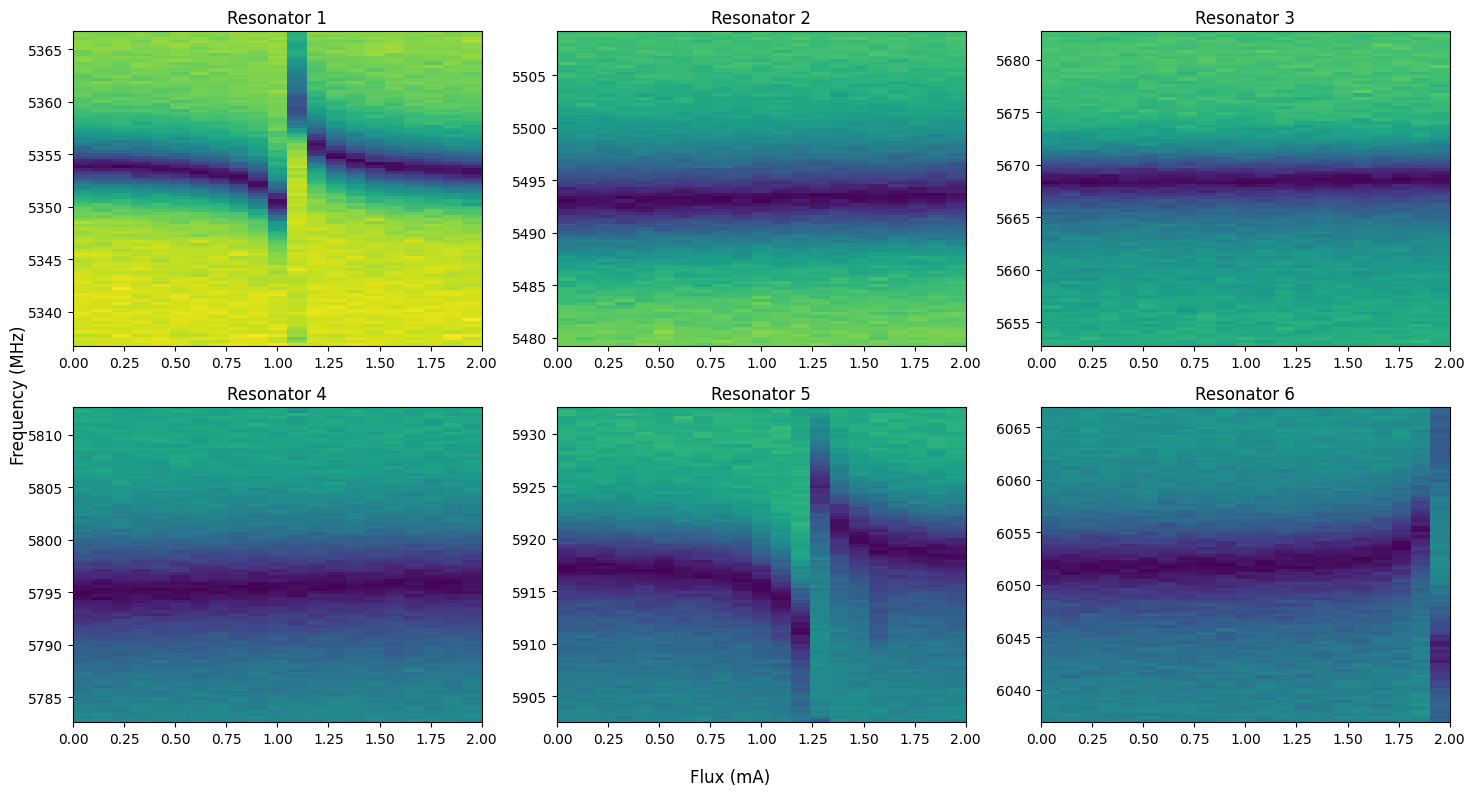

Flux Sweep:   0%|          | 0/21 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

...

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

Frequency Sweep:   0%|          | 0/101 [00:00<?, ?it/s]

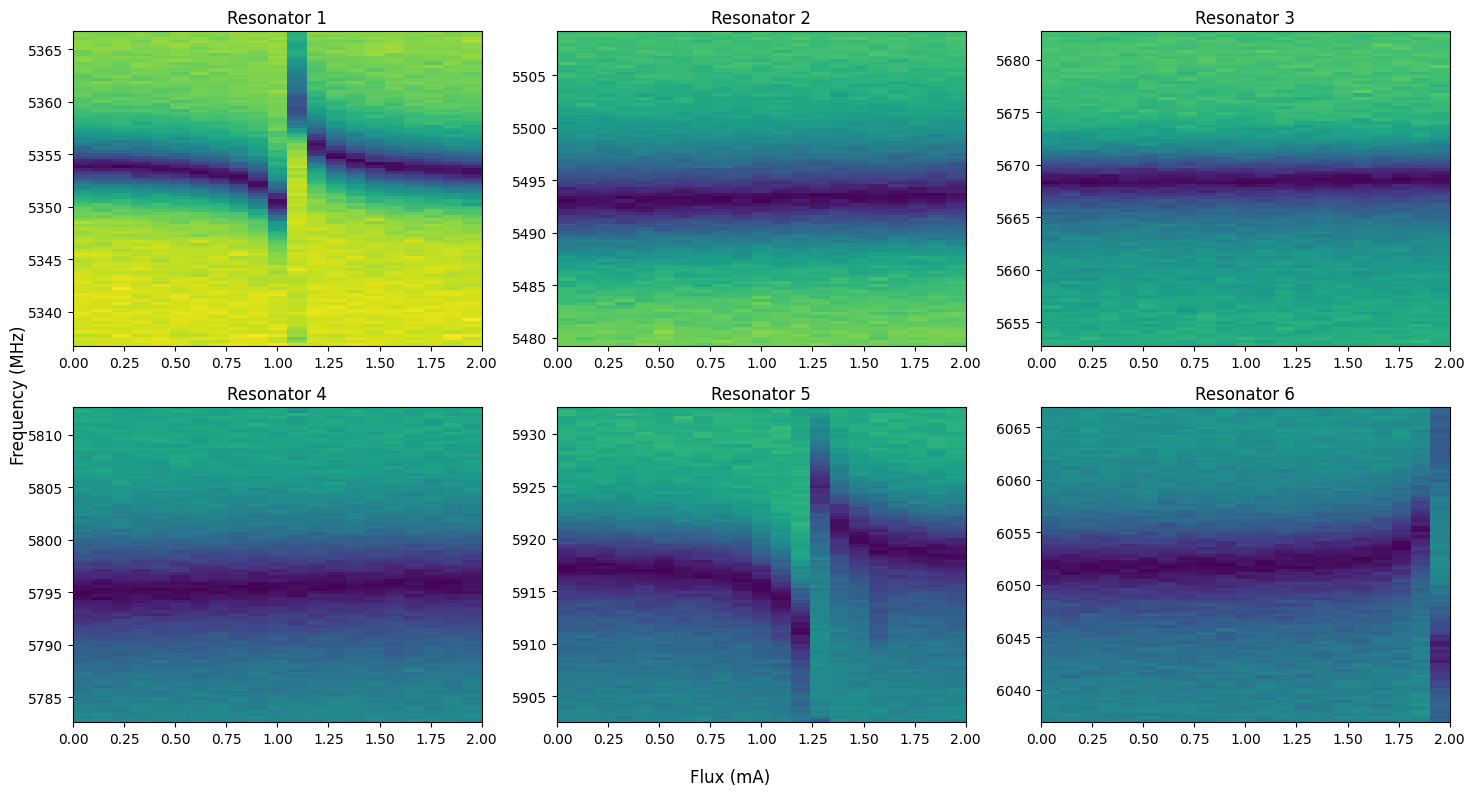

In [13]:
n_roch = 6

F_Sapn = 15
F_Steps = 101

Curr_Start = 0
Curr_Stop = 2
Curr_Step = 21

config['res_gains'] = [0.3] * n_roch
fpts = np.linspace(-F_Sapn, F_Sapn, F_Steps) 
flux = np.linspace(Curr_Start, Curr_Stop, Curr_Step) * 1e-3
sweep = np.linspace(-F_Sapn, F_Sapn, F_Steps)  

iqdata = np.zeros((len(flux), len(fpts), n_roch))


n_rows = math.ceil(n_roch / 3)
fig, ax = plt.subplots(n_rows, 3, figsize=(5 * 3, 4 * n_rows))
ax = ax.flatten() if n_rows > 1 else np.atleast_1d(ax)
fig.supxlabel("Flux (mA)")
fig.supylabel("Frequency (MHz)")
plt.subplots_adjust(left=0.07)
handle = display(fig, display_id=True)

for curr_idx, curr in enumerate(tqdm(flux, desc="Flux Sweep")):
    yoko.SetCurrent(curr)
    amp_per_flux = []

    for i in tqdm(sweep, desc="Frequency Sweep", leave=False):
        config['res_freqs'] = np.array(r) + i
        prog = MuxOneTone(soccfg, reps=100, final_delay=0.1, cfg=config)
        results = prog.acquire(soc, rounds=10, progress=False)

        amp_per_freq = []
        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amp_per_flux.append(amp_per_freq)

    for ch in range(n_roch):
        iqdata[curr_idx, :, ch] = np.abs(np.array(amp_per_flux)[:, ch])


    vmin = np.nanmin(iqdata)
    vmax = np.nanmax(iqdata)

    for i in range(n_roch):
        ax[i].clear()
        data_to_plot = iqdata[:, :, i].T

        im = ax[i].imshow(
            data_to_plot,
            aspect='auto',
            origin='lower',
            cmap='viridis',
            extent=[flux[0]*1e3, flux[-1]*1e3, fpts[0] + r[i], fpts[-1] + r[i]],
            vmin=vmin,
            vmax=vmax
        )

        ax[i].set_title(f'Resonator {i+1}')


    plt.tight_layout()
    handle.update(fig)

In [125]:
data_path = data_path

for idx in range(6):
        exp_name = f"res flux mux r{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (np.array(r)[idx] + fpts)*1e6},  
                y_info={'name': 'yoko current', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': iqdata[:, :, idx]},
                comment=f'',
                tag='OneTone'
        )

2025-07-22 11:00:25,442 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 11:00:28,170 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 11:00:30,884 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 11:00:33,626 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 11:00:36,338 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 11:00:39,052 - SR_Network:BlockingClient - Error: Socket operation timed out


## Aiming One resonator

In [ ]:
class MuxOneToneFocus(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['pulse_freqs'], 
                         mux_gains=cfg['pulse_gains'],
                         mux_phases=cfg['pulse_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['pulse_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["pulse_len"],
                       mask=[0],
                      )
        
    def _body(self, cfg):
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=True)

        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)

config = {'res_ch': 12,
          'ro_chs': [2],
          'pulse_freqs': r,
          'mixer_freq': 5750,
          'pulse_gains': [0.15],
          'pulse_phases': [0.0],
          'ro_phases': [0.0],
          'trig_time': 0.7,
          'pulse_len': 1.0,
          'ro_len': 1.2,
         }


100%|██████████| 51/51 [00:05<00:00,  9.53it/s]


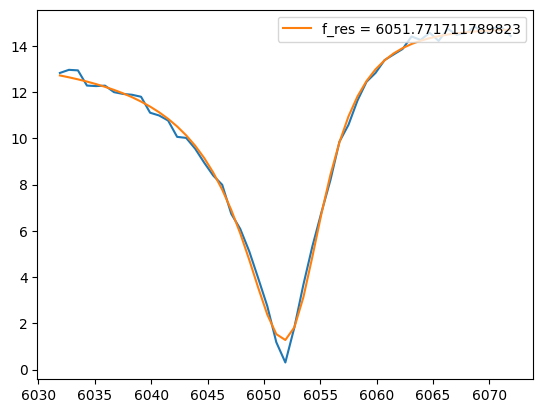

In [ ]:
res_idx = 5

initial = [r[res_idx]]
sweep = np.linspace(-20, 20, 51)
z1=[]

config['pulse_gains'] = [0.15]
for i in tqdm(sweep):
    config['pulse_freqs'] = np.array(initial)+i
    prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.5, cfg=config)
    x1, = prog.acquire(soc, soft_avgs=10, progress=False)
    z1.append(x1[0][0]+1j*x1[0][1])

## Plot ##
plt.plot(initial + sweep, np.abs(z1))
popt,_ = fit_asym_lor(initial + sweep, np.abs(z1))
plt.plot(initial + sweep, asym_lorfunc(initial + sweep, *popt), label=f'f_res = {popt[2]}')
plt.legend(loc='upper right')
res_freq = round(popt[2], 2)

## Punch out

In [ ]:
initial = [r[res_idx]]
sweep_f = np.linspace(-20, 20, 41)  # freq sweep points
sweep_g = np.linspace(0.02, 1, 20)  # gain sweep points


z = [] 

outer_loop = tqdm(sweep_g, desc="Gain Sweep")

for g in outer_loop:
    config['pulse_gains'] = [g] 
    amps = []  

    for f in (sweep_f):
        config['pulse_freqs'] = np.array(initial) + f

        prog = MuxOneToneFocus(soccfg, reps=100, final_delay=0.05, cfg=config)
        results = prog.acquire(soc, soft_avgs=10, progress=False)

        amp_per_freq = [] 

        for res in results:
            complex_val = res[0][0] + 1j * res[0][1]
            amp_per_freq.append(complex_val)

        amps.append(amp_per_freq)

    z.append(np.array(amps))

z = np.array(z)  # z.shape = (n_gain, n_freq, n_roch)


Gain Sweep: 100%|██████████| 20/20 [01:21<00:00,  4.06s/it]


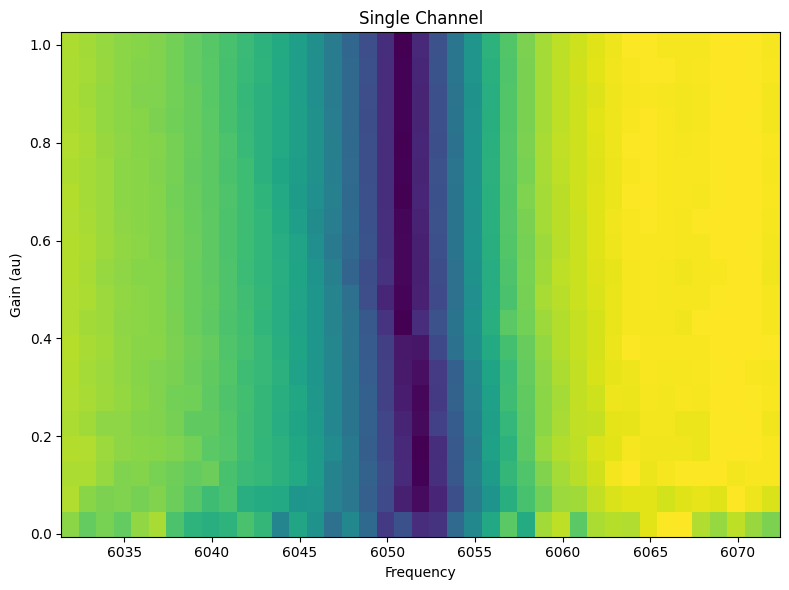

In [ ]:
fpts = sweep_f
gain = sweep_g

fig, ax = plt.subplots(figsize=(8, 6))  


data = np.abs(z[:, :, 0]) 

norm_data = np.zeros_like(data)
for i in range(data.shape[0]):  
    max_val = np.max(data[i])
    if max_val != 0:
        norm_data[i] = data[i] / max_val  
    else:
        norm_data[i] = data[i]

pcm = ax.pcolormesh(np.array(initial) + sweep_f, sweep_g, norm_data, shading='auto')

ax.set_title('Single Channel')
ax.set_xlabel('Frequency')
ax.set_ylabel('Gain (au)')

plt.tight_layout()
plt.show()


In [ ]:
data_path = data_path
exp_name = f"res pdr R{res_idx+1}"


file_path = get_next_filename_labber(data_path, exp_name)

hdf5_generator(
        filepath=file_path,
        x_info={'name': 'Frequency', 'unit': "Hz",
                'values': fpts*1e6},  
        y_info={'name': 'DAC Gain', 'unit': "a.u",
                'values': gain},
        z_info={'name': 'Signal', 'unit': 'a.u.',
                'values':  z[:, :, 0]},
        comment=f'flux at half flux',
        tag='OneTone'
)

# Mux Two Tone

In [205]:
class MuxTwoTone(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=2
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("floop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in cfg['qubit_list']:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                        style="flat_top",
                        envelope=f'ramp{i}',
                        freq=cfg[f'f_q{i+1}'],
                        phase= 0,
                        gain=cfg['q_gain'][i],
                        length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in cfg['qubit_list']:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'qubit_list': [0, 3],
          'res_freqs': fit_res,
          'mixer_freq': 6000,
          'res_gains': [0.4, 0, 0, 0.5, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }

span = 200
step = 201

qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q1': 3300 + QickSweep1D("floop", -span, span),
    'f_q4': 3600 + QickSweep1D("floop", -span, span),
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': [0.1, 0, 0, 0.3, 0.0, 0.],
    'sigma':0.05
}

run_cfg = {**config, **qb_cfg}
run_cfg['qb_ch'][0] = 0

In [206]:
prog = MuxTwoTone(soccfg, reps=100, final_delay=0.1, cfg=run_cfg)

freqs = [[]]*6
for idx in run_cfg['qubit_list']:
    freqs[idx]= prog.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)

In [215]:
yokocurrent = 0 *1e-3
yoko.SetCurrent(yokocurrent)

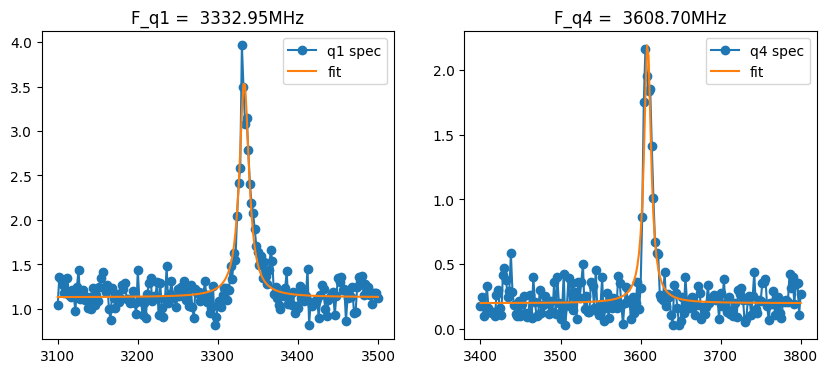

In [208]:
from data_fitting.fitting import lorfunc, fitlor

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

py_avg = 30
iq_sum = [None, None]
iq_avg = [None, None]
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}
for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, rounds=1, progress=False)

    for idx, i in enumerate(run_cfg['qubit_list']):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(freqs[i], np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)
f_q = [[] for _ in range(6)]
for idx, i in enumerate(run_cfg['qubit_list']):
    axes[idx].cla()
    axes[idx].plot(freqs[i], np.abs(iq_avg[idx]), marker='o', label=f'q{i+1} spec')
    pOpt, _ = fitlor(freqs[i], np.abs(iq_avg[idx]))
    axes[idx].plot(freqs[i], lorfunc(freqs[i], *pOpt), label='fit')

    axes[idx].legend()
    axes[idx].set_title(f'F_q{i+1} =  {pOpt[2]:.2f}MHz')
    f_q[i] = round(pOpt[2],2)


In [209]:
from yamltool import yml_comment
data_path = data_path
try:
        run_cfg.pop('f_q1')
        run_cfg.pop('f_q4')
except:
        pass
config_info = yml_comment(run_cfg)
for idx, i in enumerate([0, 3]):
        exp_name = f"qubit mux spec q{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name, yokocurrent)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': (freqs[i])*1e6},  
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(iq_avg[idx])},
                comment=f'{config_info}',
                tag='TwoTone'
        )

2025-07-25 10:03:51,570 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-25 10:03:54,658 - SR_Network:BlockingClient - Error: Socket operation timed out


## Mux Two channe flux spec

In [ ]:

Start_flux = 6 # [mA]
Stop_flux = -2 # [mA]
Steps = 161
### Flux array ###
flux = np.linspace(Start_flux, Stop_flux, Steps)*1e-3


iqlist=[]
for i in tqdm(flux):
    yoko_global.setValue(sQuant='Current', value=i, rate=10e-6)
    qspec = MuxTwoTone(soccfg, reps=100, final_delay= 0.01, cfg=run_cfg)
    iq_list = qspec.acquire(soc, soft_avgs=50, progress=False)

    iqlist.append(iq_list)
iqlist = np.array(iqlist)

100%|██████████| 51/51 [1:07:41<00:00, 79.64s/it]


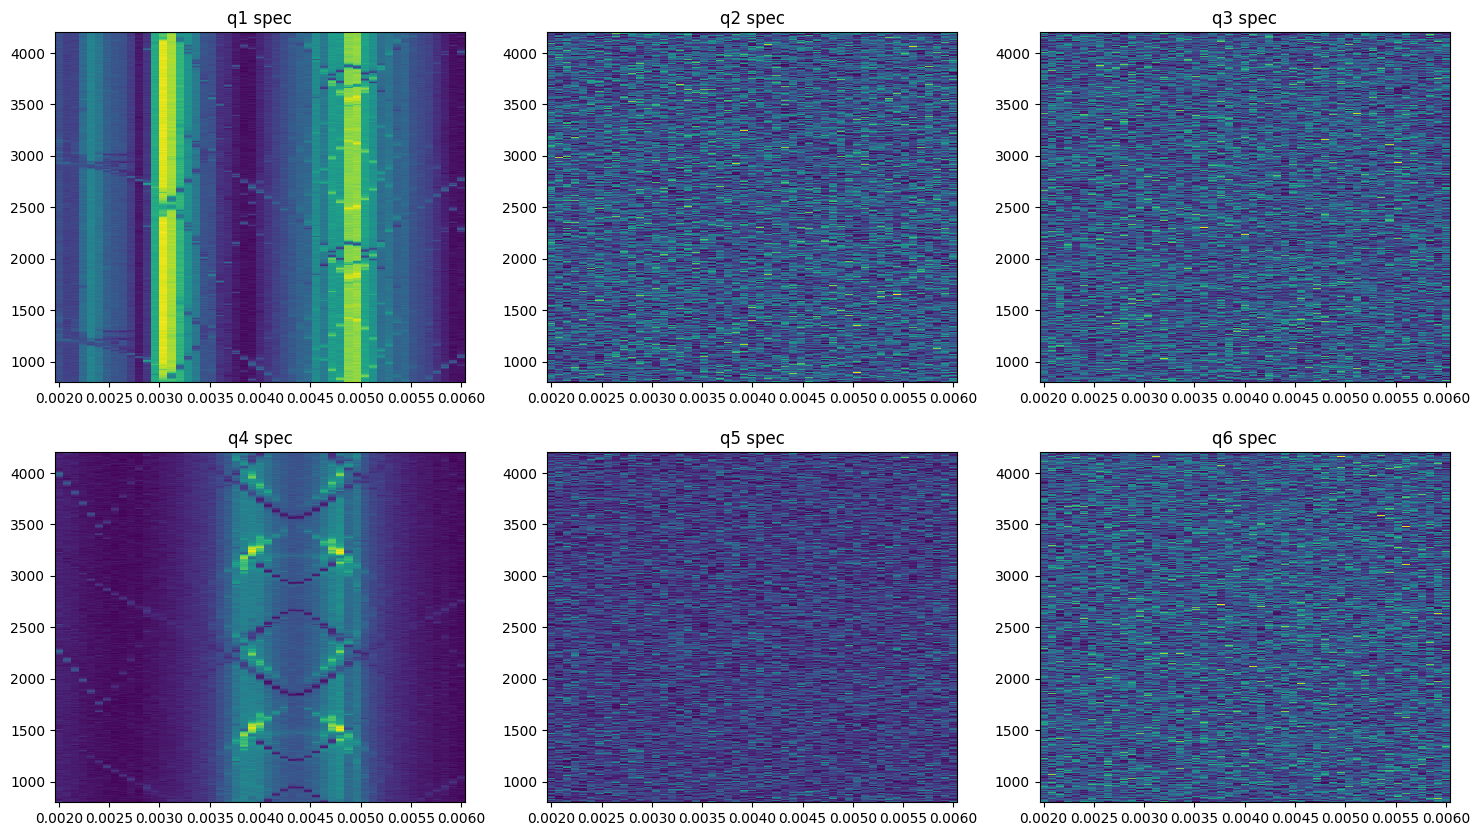

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
freqs = [[]]*6
for idx in range(6):
    freqs[idx]= qspec.get_pulse_param(f'qb{idx}_pulse', 'freq', as_array=True)
axes = axes.flatten()
q_fit=[[]]*6
for i in range(6):
    axes[i].set_title(f'q{i+1} spec')
    axes[i].pcolormesh(flux, freqs[i], np.abs(iqlist[:,i,0].dot([1,1j])).T)

In [ ]:
data_path = data_path
for i in range(6):
        exp_name = f"qubit{i} flux spec"


        file_path = get_next_filename_labber(data_path, exp_name)

        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Frequency', 'unit': "Hz",
                        'values': freqs[i]*1e6},  
                y_info={'name': 'Flux', 'unit': "A",
                        'values': flux},
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values':  np.array(iqlist)[:, i, 0].dot([1, 1j])},
                        
                comment=f'',
                tag='TwoTone mux'
        )


# PowerRabi

In [169]:
class MuxPowerRabi(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("gloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in [0,3]:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)

            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in [0,3]:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pulse", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'res_freqs': r,
          'mixer_freq': 6000,
          'res_gains': [0.4, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.7,
          'res_len': 5,
          'ro_len': 5,
         }

step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': QickSweep1D('gloop', 0, 1),
    'sigma':0.05
}
qb_cfg['qb_ch'][0] = 0
run_cfg = {**config, **qb_cfg}


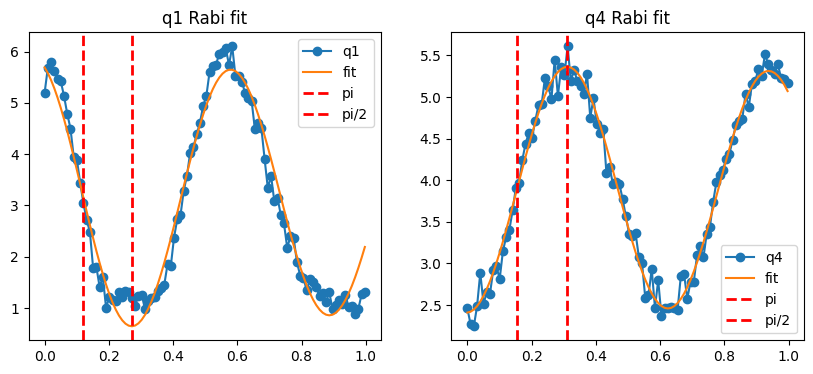

In [171]:
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

prog = MuxPowerRabi(soccfg, reps=100, final_delay=200, cfg=run_cfg)
gains = prog.get_pulse_param('qb0_pulse', 'gain', as_array=True)

py_avg = 30
iq_sum = [None, None]
iq_avg = [None, None]

for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, rounds=1, progress=False)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(gains, np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} Power Rabi average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)
prabi_fit = [[] for _ in range(6)]
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(gains, np.abs(iq_avg[idx]), marker='o', label=f'q{i+1}')
    pOpt, _ = fitdecaysin(gains, np.abs(iq_avg[idx]))
    axes[idx].plot(gains, decaysin(gains, *pOpt), label='fit')
    pi_gain, pi2_gain = pipulse_analyze(pOpt)
    axes[idx].axvline(pi_gain, ls='--', lw=2, color='r', label='pi')
    axes[idx].axvline(pi2_gain, ls='--', lw=2, color='r', label='pi/2')
    axes[idx].legend()
    axes[idx].set_title(f'q{i+1} Rabi fit')
    prabi_fit[i] = [round(pi_gain, 3), round(pi2_gain, 3)]

In [74]:
from yamltool import yml_comment
data_path = data_path
try:
        run_cfg.pop('q_gain')

except:
        pass
config_info = yml_comment(run_cfg)
for idx, i in enumerate([0, 3]):
        exp_name = f"qubit power rabi q{idx+1}"
        file_path = get_next_filename_labber(data_path, exp_name, yokocurrent)
        hdf5_generator(
                filepath=file_path,
                x_info={'name': 'Gains', 'unit': "Dac unit",
                        'values': gains},  
                z_info={'name': 'Signal', 'unit': 'a.u.',
                        'values': np.array(iq_avg[idx])},
                comment=f'{config_info}',
                tag='Rabi'
        )

2025-07-22 18:20:24,987 - SR_Network:BlockingClient - Error: Socket operation timed out
2025-07-22 18:20:25,115 - SR_Network:BlockingClient - Error: Socket operation timed out


# Ramsey

In [210]:
class MuxRamsey(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in cfg['qubit_list']:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )

    def _body(self, cfg):
        for i in cfg['qubit_list']:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse1", t=0)
        self.delay_auto(cfg['wait_time'], tag='wait')
        for i in cfg['qubit_list']:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse2", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'qubit_list': [0, 3],
          'res_freqs': r,
          'mixer_freq': 6000,
          'res_gains': [0.4, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 100
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.05,
    'wait_time': QickSweep1D('waitloop', 0, 2),
    'ramsey_freq':3
}

run_cfg = {**config, **qb_cfg}
run_cfg['qb_ch'][0] = 0

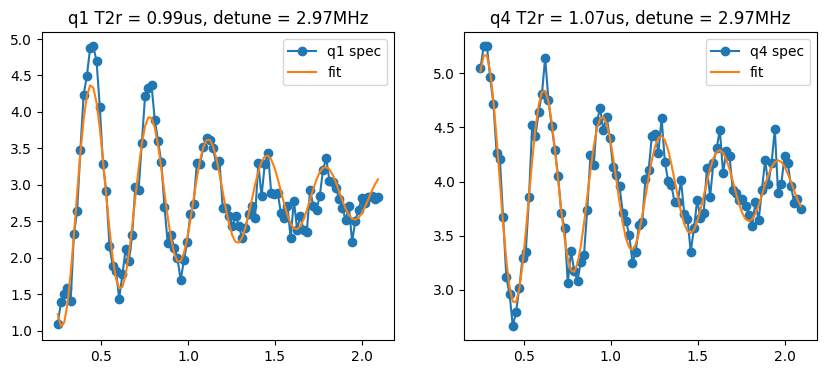

In [214]:
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

prog = MuxRamsey(soccfg, reps=100, final_delay=100, cfg=run_cfg)

delay = prog.get_time_param('wait', "t", as_array=True)

py_avg = 30
iq_sum = [None, None]
iq_avg = [None, None]

for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, soft_avgs=1, progress=False)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(delay, np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)

detune_fit=[[]]*6
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(delay, np.abs(iq_avg[idx]), marker='o', label=f'q{i+1} spec')
    pOpt, _ = fitdecaysin(delay, np.abs(iq_avg[idx]))
    axes[idx].plot(delay, decaysin(delay, *pOpt), label='fit')
    axes[idx].set_title(f'q{i+1} T2r = {pOpt[3]:.2f}us, detune = {pOpt[1]:.2f}MHz')
    axes[idx].legend()
    detune_fit[i] = round(pOpt[1],3)


In [213]:
activate_correct=True
for idx, i in enumerate([0,3]):
    pOpt, _ = fitdecaysin(delay,  np.abs(iq_avg[idx]))
    if activate_correct:
        if abs(pOpt[1]-run_cfg['ramsey_freq'])>0.0001:
            run_cfg['f_q'][i] -= round(pOpt[1]-run_cfg['ramsey_freq'],6)
            qb_cfg['f_q'][i] =  run_cfg['f_q'][i]
            f_q = run_cfg['f_q']
            print(f'q{i+1} over detune {round((pOpt[1]-run_cfg["ramsey_freq"]),6)}')
        else:
            print(f'q{i+1} over detune {round((pOpt[1]-run_cfg["ramsey_freq"]),6)}')

q1 over detune 2.764527
q4 over detune -1.460472


# Echo

In [195]:
class MuxEcho(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in cfg['qubit_list']:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse1",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi2_pulse2",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= cfg['wait_time']*360*cfg['ramsey_freq'],
                        gain=cfg['q_gain'][i][1],
                        # length=cfg["q_len"],
                        )
        for i in cfg['qubit_list']:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][0],
                        # length=cfg["q_len"],
                        )
    def _body(self, cfg):
        for i in cfg['qubit_list']:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse1", t=0)
        self.delay_auto(cfg['wait_time']/2, tag='wait')
        for i in cfg['qubit_list']:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi_pulse", t=0)
        self.delay_auto(cfg['wait_time']/2, tag='wait2')
        for i in cfg['qubit_list']:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi2_pulse2", t=0)

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'qubit_list': [0, 3],
          'res_freqs': r,
          'mixer_freq': 6000,
          'res_gains': [0.4, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 50
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.05,
    'wait_time': QickSweep1D('waitloop', 0, 8),
    'ramsey_freq':1
}

run_cfg = {**config, **qb_cfg}
run_cfg['qb_ch'][0] = 0

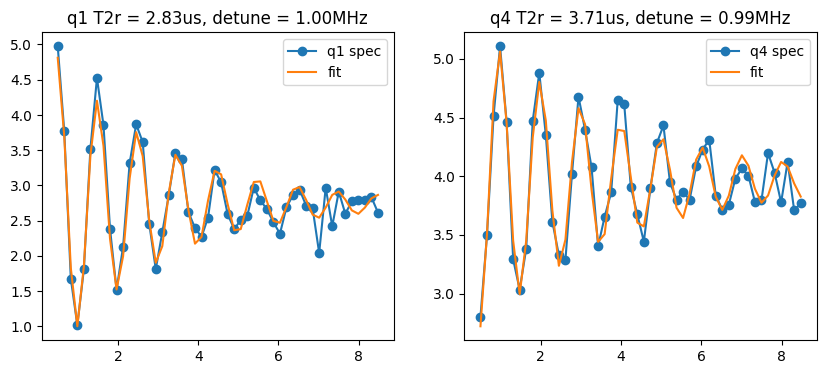

In [196]:
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

prog = MuxEcho(soccfg, reps=100, final_delay=100, cfg=run_cfg)

delay = prog.get_time_param('wait', "t", as_array=True)

py_avg = 30
iq_sum = [None, None]
iq_avg = [None, None]

for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, soft_avgs=1, progress=False)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(delay*2, np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)

detune_fit=[[]]*6
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(delay*2, np.abs(iq_avg[idx]), marker='o', label=f'q{i+1} spec')
    pOpt, _ = fitdecaysin(delay*2, np.abs(iq_avg[idx]))
    axes[idx].plot(delay*2, decaysin(delay*2, *pOpt), label='fit')
    axes[idx].set_title(f'q{i+1} T2r = {pOpt[3]:.2f}us, detune = {pOpt[1]:.2f}MHz')
    axes[idx].legend()
    detune_fit[i] = round(pOpt[1],3)


# T1

In [193]:
class MuxT1(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_chs = cfg['ro_chs']
        res_ch = cfg['res_ch']
        ##  qb_ch ##
        qb_ch=[[]]*6
        for i in [0,3]:
            qb_ch[i] = cfg['qb_ch'][i]
            nqz=1
            if soccfg['gens'][qb_ch[i]]['type']=='axis_sg_int4_v2':
                self.declare_gen(ch=q[i], nqz=nqz, mixer_freq=cfg['qmixer_freq'])
            else:
                self.declare_gen(ch=q[i], nqz=nqz)
        self.declare_gen(ch=res_ch, nqz=2, ro_ch=ro_chs[0], 
                         mixer_freq=cfg['mixer_freq'],
                         mux_freqs=cfg['res_freqs'], 
                         mux_gains=cfg['res_gains'],
                         mux_phases=cfg['res_phases'])
        for ch, f, ph in zip(cfg['ro_chs'], cfg['res_freqs'], cfg['ro_phases']):
            self.declare_readout(ch=ch, length=cfg['ro_len'], freq=f, phase=ph, gen_ch=res_ch)

        ## pulse definition ##
        self.add_loop("waitloop", self.cfg["steps"])
        self.add_pulse(ch=res_ch, name="mymux", 
                       style="const", 
                       length=cfg["res_len"],
                       mask=[0,1,2,3,4,5],
                      )
        ## qb pulse  ##
        for i in cfg['qubit_list']:
            self.add_gauss(ch=qb_ch[i], name=f"ramp{i}", sigma=cfg['sigma'], length=cfg['sigma']*5, even_length=True)
            self.add_pulse(ch=qb_ch[i], name=f"qb{i}_pi_pulse",
                        style="arb",
                        envelope=f'ramp{i}',
                        freq=cfg['f_q'][i],
                        phase= 0,
                        gain=cfg['q_gain'][i][0],
                        # length=cfg["q_len"],
                        )


    def _body(self, cfg):
        for i in cfg['qubit_list']:
            self.pulse(ch=cfg['qb_ch'][i], name=f"qb{i}_pi_pulse", t=0)
            
        self.delay_auto(cfg['wait_time'], tag='wait')

        self.delay_auto(0.05, tag='delay')
        self.trigger(ros=cfg['ro_chs'], pins=[0], t=cfg['trig_time'], ddr4=False)
        self.pulse(ch=cfg['res_ch'], name="mymux", t=0)


config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'qubit_list': [0, 3],
          'res_freqs': r,
          'mixer_freq': 6000,
          'res_gains': [0.4, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


step = 50
qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.05,
    'wait_time': QickSweep1D('waitloop', 0, 300),
    'ramsey_freq':2
}

run_cfg = {**config, **qb_cfg}
run_cfg['qb_ch'][0] = 0

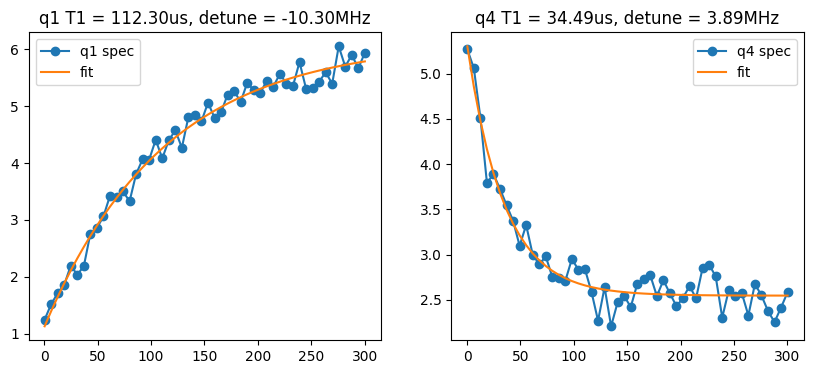

In [194]:
marker_style = {'marker': 'o', 'markersize': 5, 'alpha': 0.7, 'linestyle': '-'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

prog = MuxT1(soccfg, reps=100, final_delay=150, cfg=run_cfg)
delay = prog.get_time_param('wait', "t", as_array=True)

py_avg = 20
iq_sum = [None, None]
iq_avg = [None, None]

for avg in tqdm(range(py_avg), desc='average count'):
    iq_list = prog.acquire(soc, soft_avgs=1, progress=False)

    for idx, i in enumerate([0, 3]):
        iq_data = iq_list[i][0].dot([1, 1j])
        if avg == 0:
            iq_sum[idx] = iq_data
        else:
            iq_sum[idx] += iq_data

        iq_avg[idx] = iq_sum[idx] / (avg + 1)

        axes[idx].cla()
        axes[idx].plot(delay, np.abs(iq_avg[idx]), **marker_style)
        axes[idx].set_title(f'q{i+1} average: {avg+1} / {py_avg}')
        axes[idx].set_xlabel('Gain (Dac unit)')
        axes[idx].set_ylabel('Signal (ADC unit)')
        axes[idx].grid(True)
    clear_output(wait=True)
    display(fig)


clear_output(wait=True)

detune_fit=[[]]*6
for idx, i in enumerate([0, 3]):
    axes[idx].cla()
    axes[idx].plot(delay, np.abs(iq_avg[idx]), marker='o', label=f'q{i+1} spec')
    pOpt, _ = fitexp(delay, np.abs(iq_avg[idx]))
    axes[idx].plot(delay, expfunc(delay, *pOpt), label='fit')
    axes[idx].set_title(f'q{i+1} T1 = {pOpt[3]:.2f}us, detune = {pOpt[1]:.2f}MHz')
    axes[idx].legend()
    detune_fit[i] = round(pOpt[1],3)


In [197]:
config = {'res_ch': 12,
          'ro_chs': [2, 3, 4, 5, 6, 7],
          'qubit_list': [0, 3],
          'res_freqs': r,
          'mixer_freq': 6000,
          'res_gains': [0.4, 0, 0, 0.4, 0., 0.],
          'res_phases': [0.0]*6,
          'ro_phases': [0.0]*6,
          'trig_time': 0.75,
          'res_len': 5,
          'ro_len': 5,
         }


qb_cfg={
    'steps': step,
    'qb_ch':q,
    'f_q': f_q,
    'qmixer_freq': 3000,
    'q_len':5,
    'q_gain': prabi_fit,
    'sigma':0.05,
    'wait_time': QickSweep1D('waitloop', 0, 250),
    'ramsey_freq':1
}

run_cfg = {**config, **qb_cfg}
run_cfg['qb_ch'][0] = 0

In [200]:
import pandas as pd
import numpy as np
import time
import os

# CSV 檔名與欄位
csv_filename = "Q14_T1_T2_results_interleve.csv"
columns = ["Timestamp", "Qubit", "T1 (us)", "T1 sigma", "T2 (us)", "T2 sigma"]

# 如果檔案不存在就寫入欄位標題
if not os.path.exists(csv_filename):
    with open(csv_filename, 'w') as f:
        f.write(",".join(columns) + "\n")

try:
    while True:
        # mux2
        run_cfg['qubit_list'] = [0, 3]
        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 200), 'step': 80})
        t1 = MuxT1(soccfg, reps=100, final_delay=150, cfg=run_cfg)
        t1_iq_list = t1.acquire(soc, rounds=100, progress=False)
        t1_delay = t1.get_time_param('wait', "t", as_array=True)

        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 8), 'step': 80})
        t2 = MuxEcho(soccfg, reps=100, final_delay=150, cfg=run_cfg)
        t2_iq_list = t2.acquire(soc, rounds=100, progress=False)
        t2_delay = t2.get_time_param('wait', "t", as_array=True)

        for i in run_cfg['qubit_list']:
            qubit_label = "Qubit1" if i == 0 else "Qubit4"
            timestamp = time.strftime('%Y-%m-%d %H:%M:%S')
            t1pOpt, t1pCov = fitexp(t1_delay, np.abs(t1_iq_list[i][0].dot([1, 1j])))
            t1_sigma = np.sqrt(np.diag(t1pCov))
            t1_val, t1_sigma = t1pOpt[3], np.sqrt(np.diag(t1pCov))[3]
            t2pOpt, t2pCov = fitdecaysin(t2_delay*2, np.abs(t2_iq_list[i][0].dot([1, 1j])))
            t2_sigma = np.sqrt(np.diag(t2pCov))
            t2_val, t2_sigma = t2pOpt[3], np.sqrt(np.diag(t2pCov))[3]
            # 寫入資料行
            with open(csv_filename, 'a') as f:
                f.write(f"{timestamp},{qubit_label},{t1_val:.6f},{t1_sigma:.6f},{t2_val:.6f},{t2_sigma:.6f}\n")

            print(f"[{timestamp}] ✅ {qubit_label} 測量完成: T1 = {t1_val:.2f} ± {t1_sigma:.2f} μs, T2 = {t2_val:.2f} ± {t2_sigma:.2f} μs")

        # Q1
        run_cfg['qubit_list'] = [0]
        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 200), 'step': 100})
        t1 = MuxT1(soccfg, reps=100, final_delay=200, cfg=run_cfg)
        t1_iq_list = t1.acquire(soc, rounds=100, progress=False)
        t1_delay = t1.get_time_param('wait', "t", as_array=True)

        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 10), 'step': 100})
        t2 = MuxEcho(soccfg, reps=100, final_delay=200, cfg=run_cfg)
        t2_iq_list = t2.acquire(soc, rounds=100, progress=False)
        t2_delay = t2.get_time_param('wait', "t", as_array=True)

        for i in run_cfg['qubit_list']:
            qubit_label = "Qubit1" if i == 0 else "Qubit4"
            timestamp = time.strftime('%Y-%m-%d %H:%M:%S')
            t1pOpt, t1pCov = fitexp(t1_delay, np.abs(t1_iq_list[i][0].dot([1, 1j])))
            t1_sigma = np.sqrt(np.diag(t1pCov))
            t1_val, t1_sigma = t1pOpt[3], np.sqrt(np.diag(t1pCov))[3]
            t2pOpt, t2pCov = fitdecaysin(t2_delay*2, np.abs(t2_iq_list[i][0].dot([1, 1j])))
            t2_sigma = np.sqrt(np.diag(t2pCov))
            t2_val, t2_sigma = t2pOpt[3], np.sqrt(np.diag(t2pCov))[3]
            # 寫入資料行
            with open(csv_filename, 'a') as f:
                f.write(f"{timestamp},{qubit_label},{t1_val:.6f},{t1_sigma:.6f},{t2_val:.6f},{t2_sigma:.6f}\n")

            print(f"[{timestamp}] ✅ {qubit_label} 測量完成: T1 = {t1_val:.2f} ± {t1_sigma:.2f} μs, T2 = {t2_val:.2f} ± {t2_sigma:.2f} μs")

        # Q4
        run_cfg['qubit_list'] = [3]
        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 200), 'step': 100})
        t1 = MuxT1(soccfg, reps=100, final_delay=200, cfg=run_cfg)
        t1_iq_list = t1.acquire(soc, rounds=100, progress=False)
        t1_delay = t1.get_time_param('wait', "t", as_array=True)

        run_cfg.update({'wait_time': QickSweep1D('waitloop', 0, 10), 'step': 100})
        t2 = MuxEcho(soccfg, reps=100, final_delay=200, cfg=run_cfg)
        t2_iq_list = t2.acquire(soc, rounds=100, progress=False)
        t2_delay = t2.get_time_param('wait', "t", as_array=True)

        for i in run_cfg['qubit_list']:
            qubit_label = "Qubit1" if i == 0 else "Qubit4"
            timestamp = time.strftime('%Y-%m-%d %H:%M:%S')
            t1pOpt, t1pCov = fitexp(t1_delay, np.abs(t1_iq_list[i][0].dot([1, 1j])))
            t1_sigma = np.sqrt(np.diag(t1pCov))
            t1_val, t1_sigma = t1pOpt[3], np.sqrt(np.diag(t1pCov))[3]
            t2pOpt, t2pCov = fitdecaysin(t2_delay*2, np.abs(t2_iq_list[i][0].dot([1, 1j])))
            t2_sigma = np.sqrt(np.diag(t2pCov))
            t2_val, t2_sigma = t2pOpt[3], np.sqrt(np.diag(t2pCov))[3]
            # 寫入資料行
            with open(csv_filename, 'a') as f:
                f.write(f"{timestamp},{qubit_label},{t1_val:.6f},{t1_sigma:.6f},{t2_val:.6f},{t2_sigma:.6f}\n")

            print(f"[{timestamp}] ✅ {qubit_label} 測量完成: T1 = {t1_val:.2f} ± {t1_sigma:.2f} μs, T2 = {t2_val:.2f} ± {t2_sigma:.2f} μs")

except KeyboardInterrupt:
    print("\n🔁 測量停止（使用者中斷）")
    print("✅ CSV 資料保存在：", csv_filename)


[2025-07-24 11:08:04] ✅ Qubit1 測量完成: T1 = 96.54 ± 4.07 μs, T2 = 3.04 ± 0.20 μs
[2025-07-24 11:08:04] ✅ Qubit4 測量完成: T1 = 35.01 ± 1.16 μs, T2 = 3.52 ± 0.19 μs
[2025-07-24 11:12:27] ✅ Qubit1 測量完成: T1 = 101.70 ± 5.17 μs, T2 = 2.98 ± 0.18 μs
[2025-07-24 11:16:51] ✅ Qubit4 測量完成: T1 = 35.40 ± 1.36 μs, T2 = 3.61 ± 0.23 μs
[2025-07-24 11:20:24] ✅ Qubit1 測量完成: T1 = 112.79 ± 5.68 μs, T2 = 3.15 ± 0.23 μs
[2025-07-24 11:20:24] ✅ Qubit4 測量完成: T1 = 38.80 ± 1.34 μs, T2 = 3.59 ± 0.22 μs
[2025-07-24 11:24:47] ✅ Qubit1 測量完成: T1 = 112.32 ± 7.71 μs, T2 = 3.22 ± 0.21 μs
[2025-07-24 11:29:11] ✅ Qubit4 測量完成: T1 = 35.52 ± 1.27 μs, T2 = 3.92 ± 0.29 μs
[2025-07-24 11:32:44] ✅ Qubit1 測量完成: T1 = 96.32 ± 4.42 μs, T2 = 3.10 ± 0.22 μs
[2025-07-24 11:32:44] ✅ Qubit4 測量完成: T1 = 38.43 ± 1.63 μs, T2 = 3.89 ± 0.25 μs
[2025-07-24 11:37:07] ✅ Qubit1 測量完成: T1 = 101.20 ± 4.77 μs, T2 = 3.15 ± 0.19 μs
[2025-07-24 11:41:30] ✅ Qubit4 測量完成: T1 = 34.39 ± 1.17 μs, T2 = 3.67 ± 0.24 μs
[2025-07-24 11:45:03] ✅ Qubit1 測量完成: T1 = 116.03